# Drawing Lines — linear and logistic regression on Iris

Session 2 pre-class work. The booklet asks for two code cells:

| booklet | what it has to do |
|---|---|
| **Code Cell 1** | pull the Iris data set, fit a **linear regression**, visualize the output |
| **Code Cell 2** | pull the Iris data set, fit a **logistic regression**, visualize the output |

The two cells below are the ones to paste in. **Each is self-contained** — its own imports,
its own call to `load_iris()` — so either one runs on its own in the booklet's cell runner
without the other. Nothing is imported from this repo and nothing is downloaded: Iris ships
inside scikit-learn.

**Why both models, on the same 150 flowers?** They are the same machine underneath. Both
compute a weighted sum of the measurements, $z = \mathbf{w}\cdot\mathbf{x} + b$ — a line.
The difference is only what they do with $z$ afterwards:

- **Linear regression** hands back $z$ itself as a number, and fits by pushing it toward the
  true value (least squares). Use it when the answer is a *quantity* — here, how wide a petal is.
- **Logistic regression** squashes $z$ through a softmax into probabilities that sum to 1, and
  fits by pushing probability mass onto the true class. Use it when the answer is a *category* —
  here, which species.

So "drawing lines" is literal. Cell 1 draws one line through a cloud of points; Cell 2 draws
three lines that carve the plane into three species territories.

---

## Code Cell 1 — Linear Regression

**The question:** given how *long* a flower's petal is, how *wide* is it?

Petal length and petal width are the two most strongly related columns in Iris
(correlation ≈ 0.96), which is what makes a straight line a defensible model here rather than
a shape forced onto data that does not have it. One input feature keeps the fit drawable as
an actual line on an actual scatter plot.

The pipeline is the standard scikit-learn one, and it is worth naming the steps because every
model in this course reuses them: **load → choose X and y → split → fit → score → plot.**

The **split** matters. Scoring a model on the same rows it was fitted on tells you how well it
memorised, not how well it generalises, so 20% of the flowers are held out and never seen
during `.fit()`. Reporting both numbers is the honest version.

rows, columns: (150, 6)
missing values: 0
       petal length (cm)  petal width (cm)
count             150.00            150.00
mean                3.76              1.20
std                 1.77              0.76
min                 1.00              0.10
25%                 1.60              0.30
50%                 4.35              1.30
75%                 5.10              1.80
max                 6.90              2.50

correlation(petal length, petal width) = 0.963   <- close to 1, so a straight line is a reasonable model
train on 120 flowers | test on 30 flowers

fitted line:  petal width = 0.4132 * petal length + (-0.3567)
reading the slope: every extra 1 cm of petal length buys 0.413 cm of petal width

train  R^2 = 0.927   MSE = 0.0412 cm^2
test   R^2 = 0.928   MSE = 0.0456 cm^2


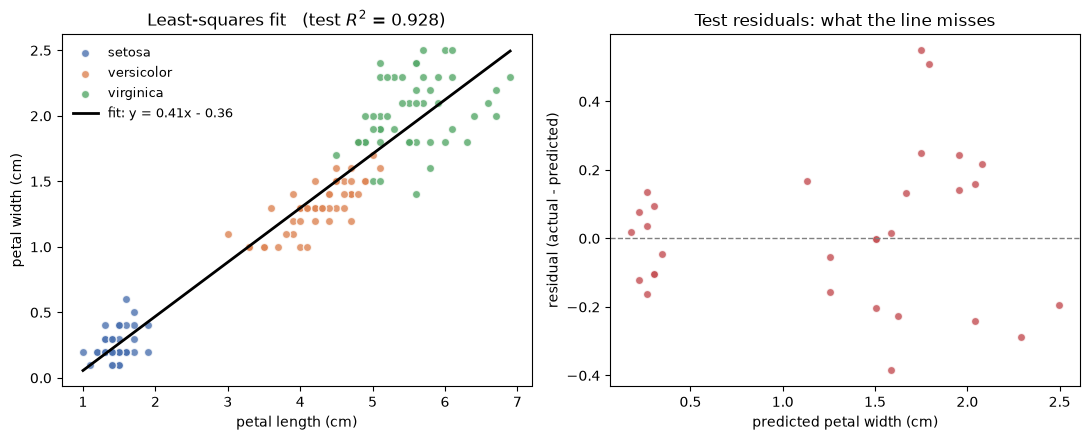

In [1]:
# ============================================================================
# CODE CELL 1 — LINEAR REGRESSION on the Iris data set
# Predict petal width (cm) from petal length (cm), then draw the fitted line.
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# --- 1. Load ---------------------------------------------------------------
# Iris: 150 flowers, 4 measurements each (all in cm), 3 species, 50 flowers per species.
# as_frame=True hands back a pandas DataFrame instead of a bare numpy array.
iris = load_iris(as_frame=True)
df = iris.frame                                       # 4 measurement columns + 'target'
df["species"] = [iris.target_names[i] for i in df["target"]]   # 0/1/2 -> readable names

print("rows, columns:", df.shape)
print("missing values:", df.isna().sum().sum())
print(df[["petal length (cm)", "petal width (cm)"]].describe().round(2))

# --- 2. Choose the input (X) and the thing being predicted (y) -------------
# X must be 2-D — one row per flower, one column per feature — even with a single feature,
# because scikit-learn always expects a design matrix. y is 1-D, one number per flower.
X = df[["petal length (cm)"]].to_numpy()              # (150, 1)
y = df["petal width (cm)"].to_numpy()                 # (150,)

r = np.corrcoef(X.ravel(), y)[0, 1]
print(f"\ncorrelation(petal length, petal width) = {r:.3f}"
      f"   <- close to 1, so a straight line is a reasonable model")

# --- 3. Split: hold out 20% the model never sees during fitting ------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)            # random_state -> same split every run
print(f"train on {X_train.shape[0]} flowers | test on {X_test.shape[0]} flowers")

# --- 4. Fit: least squares picks the slope and intercept ------------------
# It chooses the single line minimising the sum of squared vertical distances to the points.
lin = LinearRegression().fit(X_train, y_train)
slope, intercept = lin.coef_[0], lin.intercept_
print(f"\nfitted line:  petal width = {slope:.4f} * petal length + ({intercept:.4f})")
print(f"reading the slope: every extra 1 cm of petal length buys "
      f"{slope:.3f} cm of petal width")

# --- 5. Score --------------------------------------------------------------
# R^2 = fraction of the variation in petal width the line explains (1.0 = perfect).
# MSE = average squared error, in cm^2. Both are reported on train AND test:
# a big gap between them is the signature of overfitting.
pred_train, pred_test = lin.predict(X_train), lin.predict(X_test)
print(f"\ntrain  R^2 = {r2_score(y_train, pred_train):.3f}   "
      f"MSE = {mean_squared_error(y_train, pred_train):.4f} cm^2")
print(f"test   R^2 = {r2_score(y_test,  pred_test):.3f}   "
      f"MSE = {mean_squared_error(y_test,  pred_test):.4f} cm^2")

# --- 6. Visualise: the fit, and what the fit misses ------------------------
colors = {"setosa": "#4C72B0", "versicolor": "#DD8452", "virginica": "#55A868"}
fig, (ax_fit, ax_res) = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: the data coloured by species, with the single fitted line on top.
# Species is NOT an input to the model — it is drawn only to show what the line runs through.
for name, g in df.groupby("species"):
    ax_fit.scatter(g["petal length (cm)"], g["petal width (cm)"],
                   c=colors[name], label=name, s=35, alpha=.8, edgecolor="white")

grid = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
ax_fit.plot(grid, lin.predict(grid), "k-", lw=2,
            label=f"fit: y = {slope:.2f}x - {abs(intercept):.2f}")
ax_fit.set(xlabel="petal length (cm)", ylabel="petal width (cm)",
           title=f"Least-squares fit   (test $R^2$ = {r2_score(y_test, pred_test):.3f})")
ax_fit.legend(frameon=False, fontsize=9)

# Right: residuals = actual - predicted, on the held-out flowers only.
# A good fit leaves these scattered evenly around 0 with no pattern.
resid = y_test - pred_test
ax_res.scatter(pred_test, resid, c="#C44E52", s=35, alpha=.8, edgecolor="white")
ax_res.axhline(0, color="gray", ls="--", lw=1)
ax_res.set(xlabel="predicted petal width (cm)", ylabel="residual (actual - predicted)",
           title="Test residuals: what the line misses")

plt.tight_layout()
plt.show()

**Reading the output.** The fitted line comes out at roughly

$$\text{petal width} \;=\; 0.41 \times \text{petal length} \;-\; 0.36$$

with $R^2 \approx 0.93$ on the held-out flowers — the line accounts for about 93% of the
variation in petal width, and train and test agree closely, so nothing is overfitted. One
number, the slope, carries the biology: **petal width grows at about four tenths the rate of
petal length**, so iris petals keep roughly the same proportions as they get bigger.

Two things the plot shows that the metrics do not:

- **The line runs through three separate clouds.** Setosa sits in the bottom-left corner,
  tiny in both dimensions; versicolor and virginica stack up along the top-right. The model is
  never told about species — it just happens that a single straight line through all three
  clusters is a good description, which is why $R^2$ is high.
- **The residual panel is where the intercept of $-0.36$ shows up as a flaw.** A petal of
  length 0 would be predicted to have *negative* width, which is impossible. The line is a
  good local description over the range the data actually covers (1–7 cm) and nonsense outside
  it. That is the standing caveat on every regression: it is only licensed where you have data.

---

## Code Cell 2 — Logistic Regression

**The question:** given a flower's petal measurements, *which species* is it?

That is a different kind of answer — a category, not a quantity — so the model needs to output
something bounded. Logistic regression takes the same linear score $z$ and pushes it through a
**softmax**, turning three raw scores into three probabilities that sum to 1. It is fitted by
maximum likelihood, not least squares.

This cell follows scikit-learn's
[multinomial vs one-vs-rest example](https://scikit-learn.org/stable/auto_examples/linear_model/plot_logistic_multinomial.html),
with Iris substituted for that page's synthetic blobs. It fits **two** versions, because there
are two ways to stretch a fundamentally two-class method to three species:

- **Multinomial (softmax)** — one joint fit. All three classes compete in a single
  probability model, and the weights are chosen together.
- **One-vs-Rest** — three separate binary fits ("setosa or not?", "versicolor or not?",
  "virginica or not?"), each blind to the others, with the highest score winning at the end.

Only the two **petal** columns are used, out of the four available. That is a deliberate
trade: it costs a little accuracy but makes the result a 2-D picture, so the decision boundary
is something you can actually look at instead of a number you take on faith.

X: (150, 2)   flowers per species: {'setosa': 50, 'versicolor': 50, 'virginica': 50}

accuracy   multinomial 0.967   one-vs-rest 0.967

a petal of [1.4 0.2] cm is classified as:
    P(setosa    ) = 0.980
    P(versicolor) = 0.020
    P(virginica ) = 0.000

confusion matrix (rows = true species, columns = predicted)
[[50  0  0]
 [ 0 47  3]
 [ 0  2 48]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.96      0.94      0.95        50
   virginica       0.94      0.96      0.95        50

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150



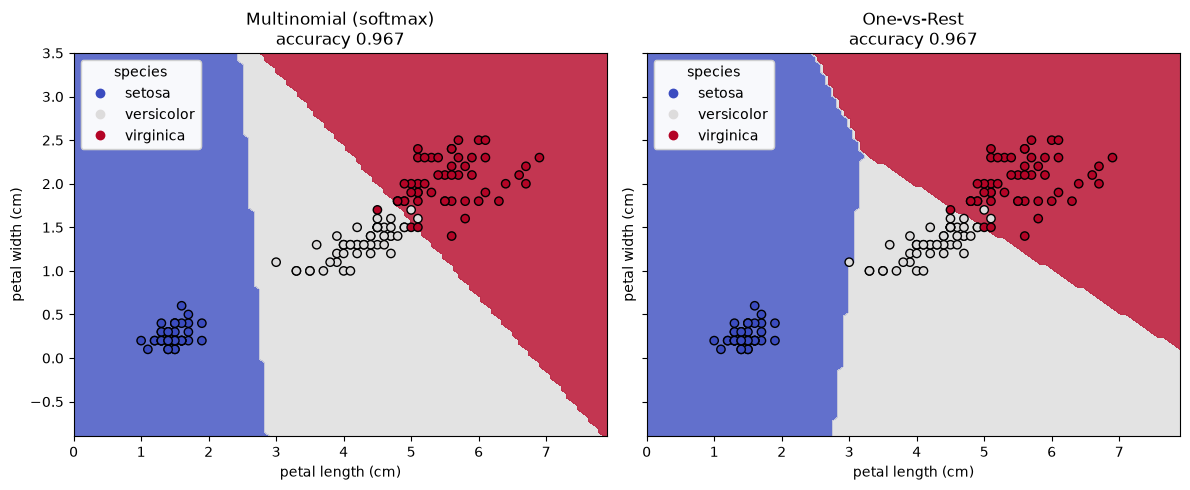

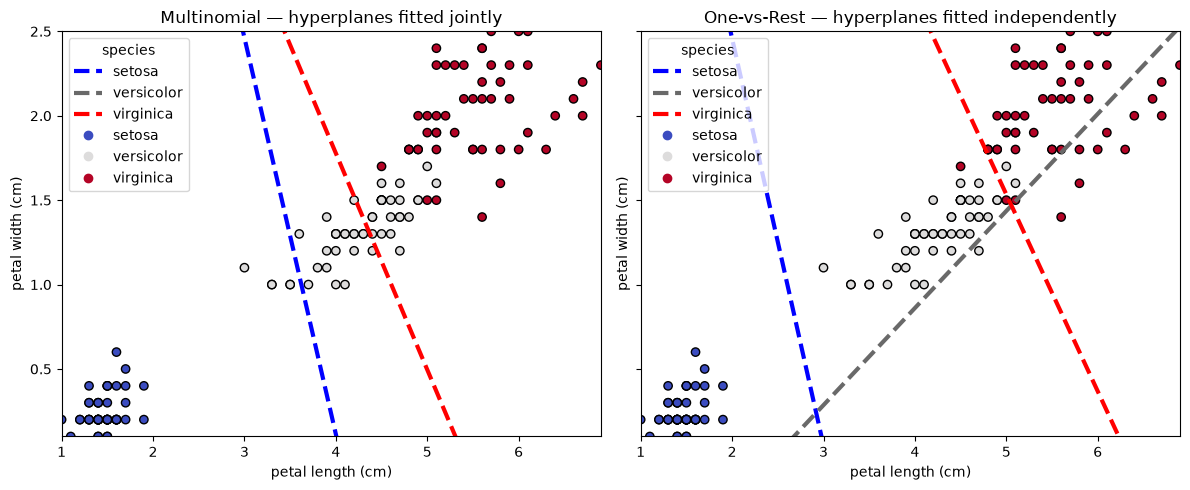

In [2]:
# ============================================================================
# CODE CELL 2 — LOGISTIC REGRESSION on the Iris data set
# Classify all three species from two petal measurements, then draw the
# decision boundary. Multinomial (softmax) vs One-vs-Rest, side by side.
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import classification_report, confusion_matrix

cmap = "coolwarm"

# --- 1. Load: keep 2 of the 4 features so the result is drawable in 2-D ----
iris = load_iris()
feat = [2, 3]                                    # petal length, petal width
X = iris.data[:, feat]                           # (150, 2) — the inputs
y = iris.target                                  # (150,)   — 0=setosa 1=versicolor 2=virginica
xlabel, ylabel = (iris.feature_names[i] for i in feat)

print("X:", X.shape, "  flowers per species:",
      {str(n): int(c) for n, c in zip(iris.target_names, np.bincount(y))})

# --- 2. Fit both flavours of multi-class logistic regression --------------
# max_iter is raised because the default 100 steps of the solver is not always
# enough to converge; it has nothing to do with the model itself.
logreg_multinomial = LogisticRegression(max_iter=1000).fit(X, y)          # one joint softmax fit
logreg_ovr = OneVsRestClassifier(LogisticRegression(max_iter=1000)).fit(X, y)  # 3 binary fits

acc_multinomial = logreg_multinomial.score(X, y)
acc_ovr = logreg_ovr.score(X, y)
print(f"\naccuracy   multinomial {acc_multinomial:.3f}   one-vs-rest {acc_ovr:.3f}")

# --- 3. The point of logistic regression: it returns probabilities --------
# Not just a label — a confidence for every class, summing to 1.
proba = logreg_multinomial.predict_proba(X[:1])[0]
print(f"\na petal of {X[0]} cm is classified as:")
for name, p in zip(iris.target_names, proba):
    print(f"    P({name:<10}) = {p:.3f}")

# --- 4. Where it gets things wrong ----------------------------------------
y_pred = logreg_multinomial.predict(X)
print("\nconfusion matrix (rows = true species, columns = predicted)")
print(confusion_matrix(y, y_pred))
print(classification_report(y, y_pred, target_names=iris.target_names))

# --- 5. Visualise: the decision boundary ----------------------------------
# DecisionBoundaryDisplay classifies every point on a fine grid across the plot
# and colours it, so the model's three territories become visible regions.
fig_boundary, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for model, title, ax in [
    (logreg_multinomial, f"Multinomial (softmax)\naccuracy {acc_multinomial:.3f}", ax1),
    (logreg_ovr,         f"One-vs-Rest\naccuracy {acc_ovr:.3f}", ax2),
]:
    DecisionBoundaryDisplay.from_estimator(
        model, X, ax=ax, response_method="predict", alpha=0.8,
        multiclass_colors=cmap, xlabel=xlabel, ylabel=ylabel)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, edgecolor="k")
    ax.add_artist(ax.legend(scatter.legend_elements()[0], iris.target_names,
                            title="species", loc="upper left"))
    ax.set_title(title)

plt.tight_layout()
plt.show()


# --- 6. Visualise: the lines the model actually learned -------------------
def plot_hyperplanes(classifier, X, ax, colors):
    """Draw each class's learned line — the set of points where w . x + b = 0."""
    xmin, xmax = X[:, 0].min(), X[:, 0].max()
    ymin, ymax = X[:, 1].min(), X[:, 1].max()
    ax.set(xlim=(xmin, xmax), ylim=(ymin, ymax))

    # One-vs-Rest keeps three independent little models; multinomial keeps one
    # coefficient matrix. Pull the weights out of whichever we were handed.
    if isinstance(classifier, OneVsRestClassifier):
        coef = np.concatenate([e.coef_ for e in classifier.estimators_])
        intercept = np.concatenate([e.intercept_ for e in classifier.estimators_])
    else:
        coef, intercept = classifier.coef_, classifier.intercept_

    # w0*x + w1*y + b = 0  rearranges to  y = (-w0/w1)*x - b/w1 — a plain line.
    for i, color in zip(range(coef.shape[0]), colors):
        w = coef[i]
        a = -w[0] / w[1]
        xx = np.linspace(xmin, xmax)
        yy = a * xx - intercept[i] / w[1]
        ax.plot(xx, yy, "--", color=color, lw=3, label=iris.target_names[i])

    return ax.get_legend_handles_labels()


fig_hyperplanes, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for model, title, ax in [
    (logreg_multinomial, "Multinomial — hyperplanes fitted jointly", ax1),
    (logreg_ovr,         "One-vs-Rest — hyperplanes fitted independently", ax2),
]:
    h_handles, h_labels = plot_hyperplanes(model, X, ax, ["blue", "dimgray", "red"])
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, edgecolor="k")
    ax.legend(h_handles + scatter.legend_elements()[0],
              h_labels + list(iris.target_names), title="species", loc="upper left")
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)

plt.tight_layout()
plt.show()

**Reading the output.** Both versions get **96.7% accuracy** — 145 of 150 flowers correct.
The confusion matrix says exactly where the five errors are, and the answer is the same story
Cell 1 told: **setosa is perfect (50/50, precision and recall both 1.00), and every single
mistake is versicolor confused with virginica.** Those two species genuinely overlap in petal
space; setosa does not come near either.

That is the useful lesson from the pictures:

- **The decision-boundary panels** show three coloured territories. The setosa boundary sits in
  a wide empty gap — there are no flowers anywhere near it, so its exact position is arbitrary
  and the model is very confident there. The versicolor/virginica boundary is jammed straight
  through a region where points of both colours sit on the wrong side of it. Same model, same
  plot, completely different confidence.
- **The hyperplane panels** show *why the two fitting strategies differ*. These dashed lines are
  not the boundaries from the previous figure — each one is where a single class's score
  $\mathbf{w}\cdot\mathbf{x}+b$ crosses zero. The setosa and virginica lines sit in nearly the
  same place under both strategies, but **the versicolor line is completely different**: under
  One-vs-Rest it cuts diagonally up through the middle of the data, while under multinomial it
  falls outside the plotted range entirely.

  That is the whole point of the comparison. One-vs-Rest fits versicolor by asking "versicolor
  vs everything else", and everything else is setosa *below* it and virginica *above* it —
  a class sandwiched in the middle cannot be cut off by one line, so the fit is incoherent on
  its own terms and only works because the final prediction takes the argmax of three scores.
  Multinomial fits all three lines at once, so versicolor never has to win alone: it wins where
  the other two both lose, and its own line is free to drift off the picture. When classes
  overlap, the joint fit is the better-posed problem, and it is why multinomial gives calibrated
  probabilities while OvR's three independent scores need not agree with each other.

A caveat on the accuracy number: unlike Cell 1, **this cell scores on the same 150 flowers it
was fitted on**, matching the scikit-learn example it is adapted from. That makes 96.7% an
optimistic ceiling rather than an estimate of performance on new flowers. Adding
`train_test_split` here — exactly as in Cell 1 — is the fix, and a natural extension if the
booklet's later cells ask for one.

---

### Repo bookkeeping

The cell below is **not part of the booklet** — it only writes the three figures to `assets/`
so they render in this session's README without anyone having to run the notebook.

In [3]:
# Repo only — save the figures produced above for the session README.
fig.savefig("assets/drawing-lines-linear-fit.png", dpi=150, bbox_inches="tight")
fig_boundary.savefig("assets/drawing-lines-decision-boundary.png", dpi=150, bbox_inches="tight")
fig_hyperplanes.savefig("assets/drawing-lines-hyperplanes.png", dpi=150, bbox_inches="tight")
print("saved 3 figures to assets/")

saved 3 figures to assets/
